In [79]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

## Dataset

In [80]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ]
)

from torch.utils.data import random_split, DataLoader

trainset = torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=transform)

train_size = int(0.8 * len(trainset))   
val_size = len(trainset) - train_size   

train_dataset, val_dataset = random_split(trainset, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
valloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## simple CNN(2 Conv layer + 2 Dense layer)

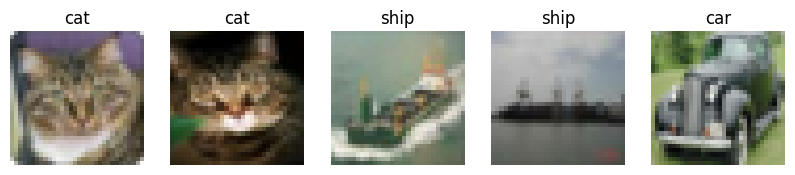

In [81]:
dataiter = iter(trainloader)
images, labels = next(dataiter)


plt.figure(figsize=(10,2))

for i in range(5):
    img = images[i] / 2 + 0.5  
    npimg = img.numpy()

    plt.subplot(1,5,i+1)
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()

In [136]:
class Network(nn.Module):
    def __init__(self):
        super(Network,self).__init__()
        self.conv1 = nn.Conv2d(3,6,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.fc1 = nn.Linear(16*5*5,120)
        self.fc2 = nn.Linear(120,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1,16*5*5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Network()

In [137]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 52,202


In [83]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=0.001,momentum=0.9)

In [108]:
def train(model, epochs, trainloader, valloader, criterion, optimizer, patience=None,l1_lambda = None):
    
    train_losses = []
    val_losses = []

    if patience == None:
        patience = float('inf')
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        
        # training
        model.train()
        running_train_loss = 0.0
        
        for inputs, labels in trainloader:
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            if l1_lambda is not None:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
               
                loss = loss + l1_lambda * l1_norm
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
        
        
        epoch_train_loss = running_train_loss / len(trainloader)
        train_losses.append(epoch_train_loss)
        
        # validation
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in valloader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
        
        epoch_val_loss = running_val_loss / len(valloader)
        val_losses.append(epoch_val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} "
              f"Val Loss: {epoch_val_loss:.4f}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"EarlyStopping counter: {epochs_no_improve} out of {patience}")
            
            if epochs_no_improve >= patience:
                print("Early stopping triggered!")
                break
    
    # graph
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.show()

Epoch [1/40] Train Loss: 2.2056 Val Loss: 2.0354
Epoch [2/40] Train Loss: 1.9338 Val Loss: 1.8295
Epoch [3/40] Train Loss: 1.7608 Val Loss: 1.7023
Epoch [4/40] Train Loss: 1.6575 Val Loss: 1.6111
Epoch [5/40] Train Loss: 1.5710 Val Loss: 1.5587
Epoch [6/40] Train Loss: 1.5008 Val Loss: 1.4902
Epoch [7/40] Train Loss: 1.4486 Val Loss: 1.4653
Epoch [8/40] Train Loss: 1.4010 Val Loss: 1.3891
Epoch [9/40] Train Loss: 1.3562 Val Loss: 1.3560
Epoch [10/40] Train Loss: 1.3191 Val Loss: 1.3197
Epoch [11/40] Train Loss: 1.2831 Val Loss: 1.3000
Epoch [12/40] Train Loss: 1.2560 Val Loss: 1.2872
Epoch [13/40] Train Loss: 1.2298 Val Loss: 1.2490
Epoch [14/40] Train Loss: 1.1976 Val Loss: 1.2239
Epoch [15/40] Train Loss: 1.1785 Val Loss: 1.2358
Epoch [16/40] Train Loss: 1.1530 Val Loss: 1.2151
Epoch [17/40] Train Loss: 1.1338 Val Loss: 1.1764
Epoch [18/40] Train Loss: 1.1153 Val Loss: 1.1811
Epoch [19/40] Train Loss: 1.0927 Val Loss: 1.1759
Epoch [20/40] Train Loss: 1.0748 Val Loss: 1.1510
Epoch [21

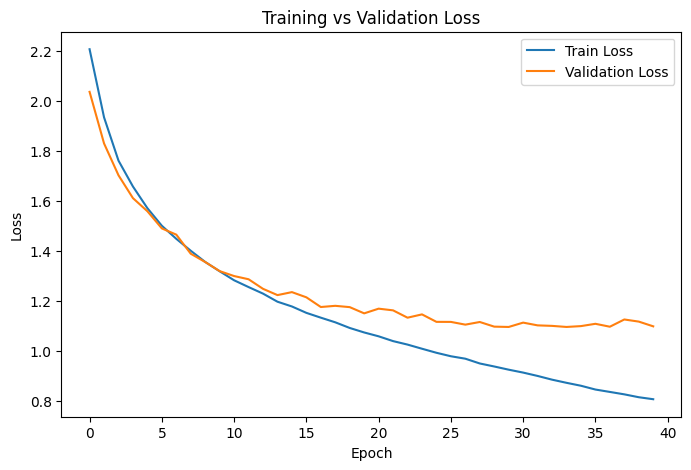

In [85]:
train(model,40,trainloader,valloader,criterion,optimizer)

In [86]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 63 %


## insights from 2 conv 2 dense layer network
as the number of epochs are increased the traning loss keep going down, validation loss also followed the same curve as training loss but after about epoch 15 it started becoming flat showing no improvements probably cause very simply and small architecture. the testing accuracy of 64% is also shows the model is simply and small

## bigger CNN Network with BatchNormalization (3 conv + 3 Dense Layer)

In [138]:
class BetterNetwork(nn.Module):
    def __init__(self):
        super(BetterNetwork, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = x.view(-1, 128 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
model = BetterNetwork()

In [139]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 1,209,738


In [95]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=0.001,momentum=0.9)

Epoch [1/20] Train Loss: 1.6961 Val Loss: 1.3363
Epoch [2/20] Train Loss: 1.1995 Val Loss: 1.1160
Epoch [3/20] Train Loss: 1.0023 Val Loss: 0.9990
Epoch [4/20] Train Loss: 0.8911 Val Loss: 0.9178
Epoch [5/20] Train Loss: 0.7987 Val Loss: 0.8916
Epoch [6/20] Train Loss: 0.7307 Val Loss: 0.8544
Epoch [7/20] Train Loss: 0.6669 Val Loss: 0.8512
Epoch [8/20] Train Loss: 0.6038 Val Loss: 0.7881
Epoch [9/20] Train Loss: 0.5549 Val Loss: 0.7887
Epoch [10/20] Train Loss: 0.4942 Val Loss: 0.8353
Epoch [11/20] Train Loss: 0.4601 Val Loss: 0.7941
Epoch [12/20] Train Loss: 0.4133 Val Loss: 0.7925
Epoch [13/20] Train Loss: 0.3691 Val Loss: 0.8036
Epoch [14/20] Train Loss: 0.3265 Val Loss: 0.8483
Epoch [15/20] Train Loss: 0.2969 Val Loss: 0.8691
Epoch [16/20] Train Loss: 0.2548 Val Loss: 0.8988
Epoch [17/20] Train Loss: 0.2271 Val Loss: 0.9699
Epoch [18/20] Train Loss: 0.2027 Val Loss: 0.9476
Epoch [19/20] Train Loss: 0.1577 Val Loss: 0.9584
Epoch [20/20] Train Loss: 0.1375 Val Loss: 1.0179


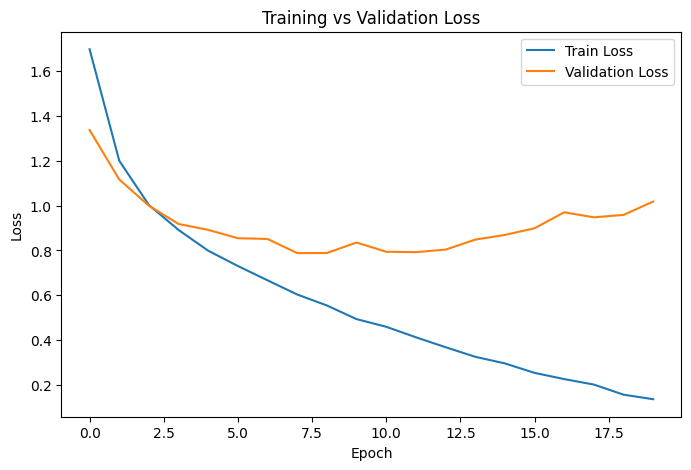

In [96]:
train(model,20,trainloader,valloader,criterion,optimizer)

In [97]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 73 %


## insights for bigger model with batch normalization
the over training accuracy is very less compare to previous model even after running for less number epochs,how there is clear overfitting we can see from the graph on validation set due to the bigger size of the model having more than 1 million params, yet it has better in testset then simple previous model

## Early Stopping + Adam

In [101]:
model = BetterNetwork() ## reinitialise the model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-8,
)


Epoch [1/20] Train Loss: 1.2475 Val Loss: 0.9870
Epoch [2/20] Train Loss: 0.8590 Val Loss: 0.9369
Epoch [3/20] Train Loss: 0.7063 Val Loss: 0.7828
Epoch [4/20] Train Loss: 0.6002 Val Loss: 0.7217
Epoch [5/20] Train Loss: 0.5084 Val Loss: 0.7020
Epoch [6/20] Train Loss: 0.4357 Val Loss: 0.7097
EarlyStopping counter: 1 out of 4
Epoch [7/20] Train Loss: 0.3593 Val Loss: 0.6782
Epoch [8/20] Train Loss: 0.2956 Val Loss: 0.7319
EarlyStopping counter: 1 out of 4
Epoch [9/20] Train Loss: 0.2496 Val Loss: 0.7487
EarlyStopping counter: 2 out of 4
Epoch [10/20] Train Loss: 0.1957 Val Loss: 0.8078
EarlyStopping counter: 3 out of 4
Epoch [11/20] Train Loss: 0.1602 Val Loss: 0.8373
EarlyStopping counter: 4 out of 4
Early stopping triggered!


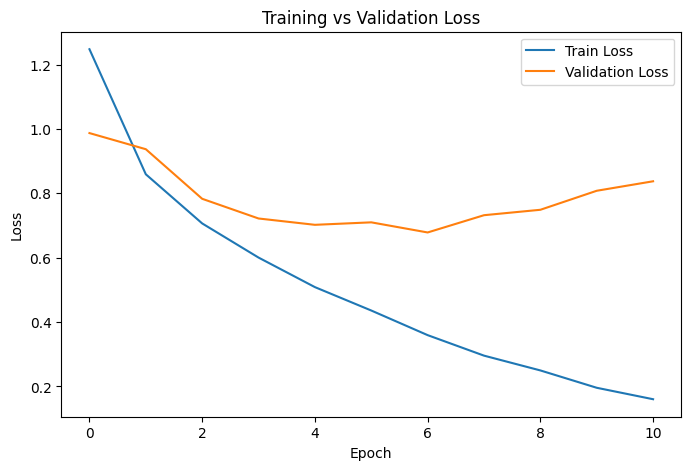

In [103]:
train(model,20,trainloader,valloader,criterion,optimizer,4)


In [107]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 78 %


## insights for early stopping and Adam optimzier
as we can see from the first epoch itself, Adam has the best start and very high speed convergence, as it reach the training loss of less 0.2 within 10 epochs compare 20 and 40 in previous models, also we can see that early stopping forced the model to stop at epoch 11 after a patience check on 4 consecutive epochs, and hence testing accuracy also increased from 74--> 78%

## L1 and L2 regularisation

In [117]:
model = BetterNetwork() ## reinitialise the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)


Epoch [1/15] Train Loss: 1.8782 Val Loss: 1.0874
Epoch [2/15] Train Loss: 1.4154 Val Loss: 0.9058
Epoch [3/15] Train Loss: 1.2538 Val Loss: 0.8450
Epoch [4/15] Train Loss: 1.1518 Val Loss: 0.7987
Epoch [5/15] Train Loss: 1.0800 Val Loss: 0.9362
EarlyStopping counter: 1 out of inf
Epoch [6/15] Train Loss: 1.0332 Val Loss: 0.8527
EarlyStopping counter: 2 out of inf
Epoch [7/15] Train Loss: 0.9920 Val Loss: 0.6904
Epoch [8/15] Train Loss: 0.9527 Val Loss: 0.7022
EarlyStopping counter: 1 out of inf
Epoch [9/15] Train Loss: 0.9411 Val Loss: 0.6934
EarlyStopping counter: 2 out of inf
Epoch [10/15] Train Loss: 0.9218 Val Loss: 0.6783
Epoch [11/15] Train Loss: 0.8822 Val Loss: 0.6823
EarlyStopping counter: 1 out of inf
Epoch [12/15] Train Loss: 0.8651 Val Loss: 0.7056
EarlyStopping counter: 2 out of inf
Epoch [13/15] Train Loss: 0.8385 Val Loss: 0.7629
EarlyStopping counter: 3 out of inf
Epoch [14/15] Train Loss: 0.8101 Val Loss: 0.8131
EarlyStopping counter: 4 out of inf
Epoch [15/15] Train L

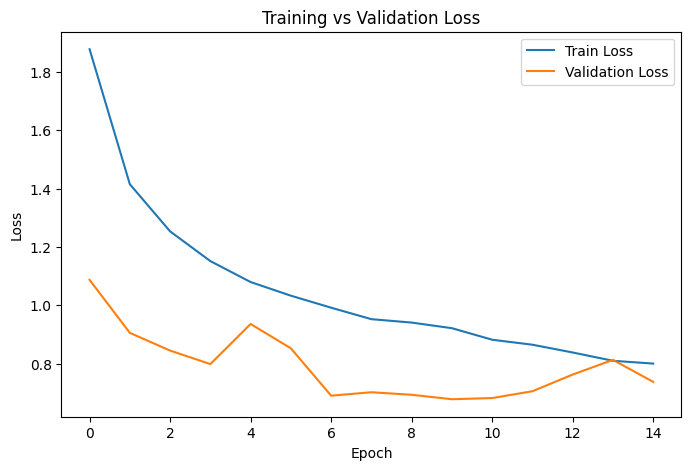

In [118]:
train(model,15,trainloader,valloader,criterion,optimizer,None,0.0001)

In [119]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 75 %


## insights
we can see that adding l1 and l2 regularisation has decreased the difference beween training and validation loss significantly while still achieving 75% accuracy

## Dropout + L2

In [123]:
class DropoutNetwork(nn.Module):
    def __init__(self):
        super(DropoutNetwork, self).__init__()
        
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = x.view(-1, 128 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        
        x = self.fc3(x)
        
        return x


In [124]:
model = DropoutNetwork() ## reinitialise the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)


Epoch [1/15] Train Loss: 1.5634 Val Loss: 1.3409
Epoch [2/15] Train Loss: 1.1810 Val Loss: 1.0041
Epoch [3/15] Train Loss: 1.0253 Val Loss: 0.9064
Epoch [4/15] Train Loss: 0.9277 Val Loss: 0.8888
Epoch [5/15] Train Loss: 0.8470 Val Loss: 0.7692
Epoch [6/15] Train Loss: 0.7699 Val Loss: 0.7363
Epoch [7/15] Train Loss: 0.7190 Val Loss: 0.6863
Epoch [8/15] Train Loss: 0.6648 Val Loss: 0.7610
EarlyStopping counter: 1 out of inf
Epoch [9/15] Train Loss: 0.6043 Val Loss: 0.6595
Epoch [10/15] Train Loss: 0.5666 Val Loss: 0.7265
EarlyStopping counter: 1 out of inf
Epoch [11/15] Train Loss: 0.5171 Val Loss: 0.6337
Epoch [12/15] Train Loss: 0.4866 Val Loss: 0.6733
EarlyStopping counter: 1 out of inf
Epoch [13/15] Train Loss: 0.4482 Val Loss: 0.6705
EarlyStopping counter: 2 out of inf
Epoch [14/15] Train Loss: 0.4198 Val Loss: 0.6823
EarlyStopping counter: 3 out of inf
Epoch [15/15] Train Loss: 0.3822 Val Loss: 0.7324
EarlyStopping counter: 4 out of inf


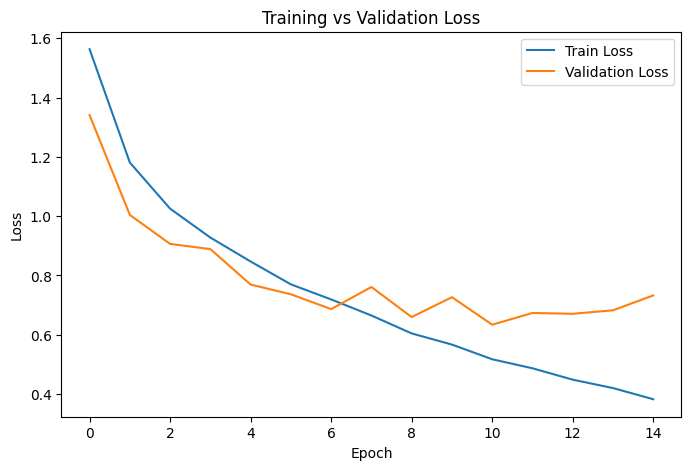

In [125]:
train(model,15,trainloader,valloader,criterion,optimizer,None,0)

In [126]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 77 %


## insights for Dropout  + L2 + Early stopping
as we can see the training loss goes significantly lower then sole l1+l2 regularisation, also the testing accuracy has improved from 75 to 77%

## Data Augmentation 

In [132]:
from torch.utils.data import random_split, DataLoader, Subset


train_transform = transforms.Compose([

    transforms.RandomCrop(32, padding=4),
    
    transforms.RandomHorizontalFlip(),

    # transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),

    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)

dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

generator = torch.Generator().manual_seed(42) 
train_indices, val_indices = random_split(range(dataset_size), [train_size, val_size], generator=generator)

train_set_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_set_full   = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=test_transform)

train_dataset = Subset(train_set_full, train_indices.indices)
val_dataset   = Subset(val_set_full, val_indices.indices)



trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
valloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [133]:
model = DropoutNetwork() ## reinitialise the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)


Epoch [1/25] Train Loss: 1.7320 Val Loss: 1.3850
Epoch [2/25] Train Loss: 1.4229 Val Loss: 1.2387
Epoch [3/25] Train Loss: 1.2798 Val Loss: 1.2452
EarlyStopping counter: 1 out of 4
Epoch [4/25] Train Loss: 1.1872 Val Loss: 0.9436
Epoch [5/25] Train Loss: 1.1073 Val Loss: 0.8902
Epoch [6/25] Train Loss: 1.0463 Val Loss: 0.8361
Epoch [7/25] Train Loss: 0.9921 Val Loss: 0.8174
Epoch [8/25] Train Loss: 0.9470 Val Loss: 0.8004
Epoch [9/25] Train Loss: 0.9206 Val Loss: 0.7543
Epoch [10/25] Train Loss: 0.8812 Val Loss: 0.7189
Epoch [11/25] Train Loss: 0.8621 Val Loss: 0.6810
Epoch [12/25] Train Loss: 0.8347 Val Loss: 0.6480
Epoch [13/25] Train Loss: 0.8042 Val Loss: 0.6962
EarlyStopping counter: 1 out of 4
Epoch [14/25] Train Loss: 0.7910 Val Loss: 0.7282
EarlyStopping counter: 2 out of 4
Epoch [15/25] Train Loss: 0.7596 Val Loss: 0.6489
EarlyStopping counter: 3 out of 4
Epoch [16/25] Train Loss: 0.7471 Val Loss: 0.6167
Epoch [17/25] Train Loss: 0.7330 Val Loss: 0.6241
EarlyStopping counter: 

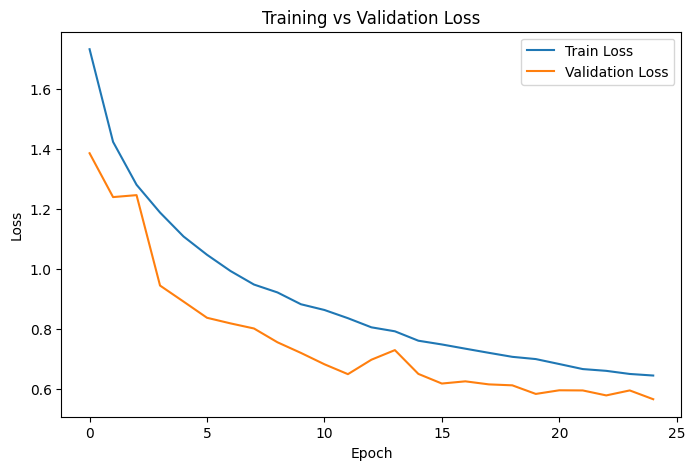

In [134]:
train(model,25,trainloader,valloader,criterion,optimizer,4,0)

In [135]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 80 %


## Insights for Data Augmentation + Dropout + L2 Regularization
As we can see, after data augmentation the model achieves the best accuracy so far of 80%, and by looking at the graph, more training might result in even better results. This is probably because there is more data to learn from after augmentation.